In [26]:
import numpy as np
import matplotlib.pyplot as plt
%run geminiGeneratedHelper.ipynb 

def create_sfcw_comparison_figure(
    ascan_cw: np.ndarray,
    compensated_response_cw: np.ndarray,
    uncompensated_response_cw: np.ndarray,
    ascan_chirp: np.ndarray,
    compensated_response_chirp: np.ndarray,
    uncompensated_response_chirp: np.ndarray,
    start_freq_hz: float,
    step_freq_hz: float,
    output_filename: str = "sfcw_comparison.png"
):
    """
    Generates a 2x3 figure comparing results from CW and LFM Chirp experiments.

    Top Row (CW):    (a) A-scan | (b) Compensated Phase | (c) Uncompensated Phase
    Bottom Row (Chirp): (d) A-scan | (e) Compensated Phase | (f) Uncompensated Phase
    """
    # --- 1. Configure Matplotlib for Publication Quality ---
    plt.rcParams.update({
        'font.size': 10, 'axes.labelsize': 10, 'axes.titlesize': 12,
        'xtick.labelsize': 8, 'ytick.labelsize': 8, 'figure.dpi': 300,
        'savefig.dpi': 300, 'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    })

    # --- 2. Prepare Data for Plotting ---
    num_steps = len(compensated_response_cw)
    freq_axis = np.linspace(start_freq_hz, start_freq_hz + (num_steps - 1) * step_freq_hz, num_steps) / 1e9  # in GHz
    range_axis_cw = np.arange(len(ascan_cw))
    range_axis_chirp = np.arange(len(ascan_chirp))

    # Normalize A-scans to 0 dB peak
    ascan_db_cw = 20 * np.log10(np.abs(ascan_cw) / np.max(np.abs(ascan_cw)) + 1e-9)
    ascan_db_chirp = 20 * np.log10(np.abs(ascan_chirp) / np.max(np.abs(ascan_chirp)) + 1e-9)

    # Extract phases
    comp_phase_cw = np.angle(compensated_response_cw)
    uncomp_phase_cw = np.angle(uncompensated_response_cw)
    comp_phase_chirp = np.angle(compensated_response_chirp)
    uncomp_phase_chirp = np.angle(uncompensated_response_chirp)

    # --- 3. Create the 2x3 Figure ---
    fig, axs = plt.subplots(2, 3, figsize=(12, 6))

    # --- TOP ROW: SINGLE-TONE CW RESULTS ---
    axs[0, 0].plot(range_axis_cw, ascan_db_cw)
    axs[0, 0].set_title('(a) Range Profile (CW)')
    axs[0, 0].set_xlabel('Range Bin'); axs[0, 0].set_ylabel('Magnitude (dB)'); axs[0, 0].grid(True, linestyle=':'); axs[0, 0].set_ylim(-70, 5)

    axs[0, 1].plot(freq_axis, comp_phase_cw, '-', linewidth=2, color='C1')
    axs[0, 1].set_title('(b) Compensated Phase (CW)')
    axs[0, 1].set_xlabel('Frequency (GHz)'); axs[0, 1].set_ylabel('Phase (radians)'); axs[0, 1].grid(True, linestyle=':')

    # --- MODIFICATION START ---
    axs[0, 2].plot(freq_axis, uncomp_phase_cw, '-', linewidth=1, alpha=0.8, color='C0')
    # --- MODIFICATION END ---
    axs[0, 2].set_title('(c) Uncompensated Phase (CW)')
    axs[0, 2].set_xlabel('Frequency (GHz)'); axs[0, 2].set_ylabel('Phase (radians)'); axs[0, 2].grid(True, linestyle=':'); axs[0, 2].set_ylim(-np.pi * 1.2, np.pi * 1.2)

    # --- BOTTOM ROW: LFM CHIRP RESULTS ---
    axs[1, 0].plot(range_axis_chirp, ascan_db_chirp)
    axs[1, 0].set_title('(d) Range Profile (Chirp)')
    axs[1, 0].set_xlabel('Range Bin'); axs[1, 0].set_ylabel('Magnitude (dB)'); axs[1, 0].grid(True, linestyle=':'); axs[1, 0].set_ylim(-70, 5)

    axs[1, 1].plot(freq_axis, comp_phase_chirp, '-', linewidth=2, color='C1')
    axs[1, 1].set_title('(e) Compensated Phase (Chirp)')
    axs[1, 1].set_xlabel('Frequency (GHz)'); axs[1, 1].set_ylabel('Phase (radians)'); axs[1, 1].grid(True, linestyle=':')
    
    # --- MODIFICATION START ---
    axs[1, 2].plot(freq_axis, uncomp_phase_chirp, '-', linewidth=1, alpha=0.8, color='C0')
    # --- MODIFICATION END ---
    axs[1, 2].set_title('(f) Uncompensated Phase (Chirp)')
    axs[1, 2].set_xlabel('Frequency (GHz)'); axs[1, 2].set_ylabel('Phase (radians)'); axs[1, 2].grid(True, linestyle=':'); axs[1, 2].set_ylim(-np.pi * 1.2, np.pi * 1.2)

    # --- 4. Finalize and Save Figure ---
    plt.tight_layout(pad=1.0)
    plt.savefig(output_filename, bbox_inches='tight')
    print(f"Figure saved as '{output_filename}'")
    plt.show()

In [27]:
SAMPLING_RATE = 5e6    # 5 MHz
BASEBAND_FREQ = 100e3   # 100 kHz
burst_len = 1024 + 128
num_steps = 128
supposed_size = burst_len*num_steps
dir = '/home/hui/bladerf_sfcw_radar/data/'
prefix = 'loop_back_cw_highGain'
i=0
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
cut_off = 2.4e6
transition_width = 1e6
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_cw, compensated_response_cw, uncompensated_response_cw = generate_ascan_from_cw(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    baseband_freq_hz=BASEBAND_FREQ,
    sampling_rate_hz=SAMPLING_RATE
)

# plotResults(ascan_profile, calibrated_channel_response, echo_response)

# calculate_snr(ascan_profile)

SAMPLING_RATE = 10e6    # 5 MHz
CHIRP_BANDWIDTH = 2e6  # 1 MHz
burst_len = 1024
num_steps = 128
supposed_size = burst_len*num_steps
dir = '/home/hui/bladerf_sfcw_radar/data/'
prefix = 'loop_back_chirp_highGain'
i=0
cut_off = 2.4e6
transition_width = 1e6
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps, transition_width, cut_off)

# --- Generate the A-scan using the function ---
ascan_chirp, compensated_response_chirp, uncompensated_response_chirp = generate_ascan_from_lfm(
    echo_signals=rx_samples,
    reference_signals=ref_samples,
    num_steps=num_steps,
    step_length=burst_len,
    chirp_bandwidth=CHIRP_BANDWIDTH,
    sampling_rate_hz=SAMPLING_RATE
)

# plotResults(ascan_profile, calibrated_channel_response, echo_response)

# calculate_snr(ascan_profile)

Figure saved as 'phase_validation.png'


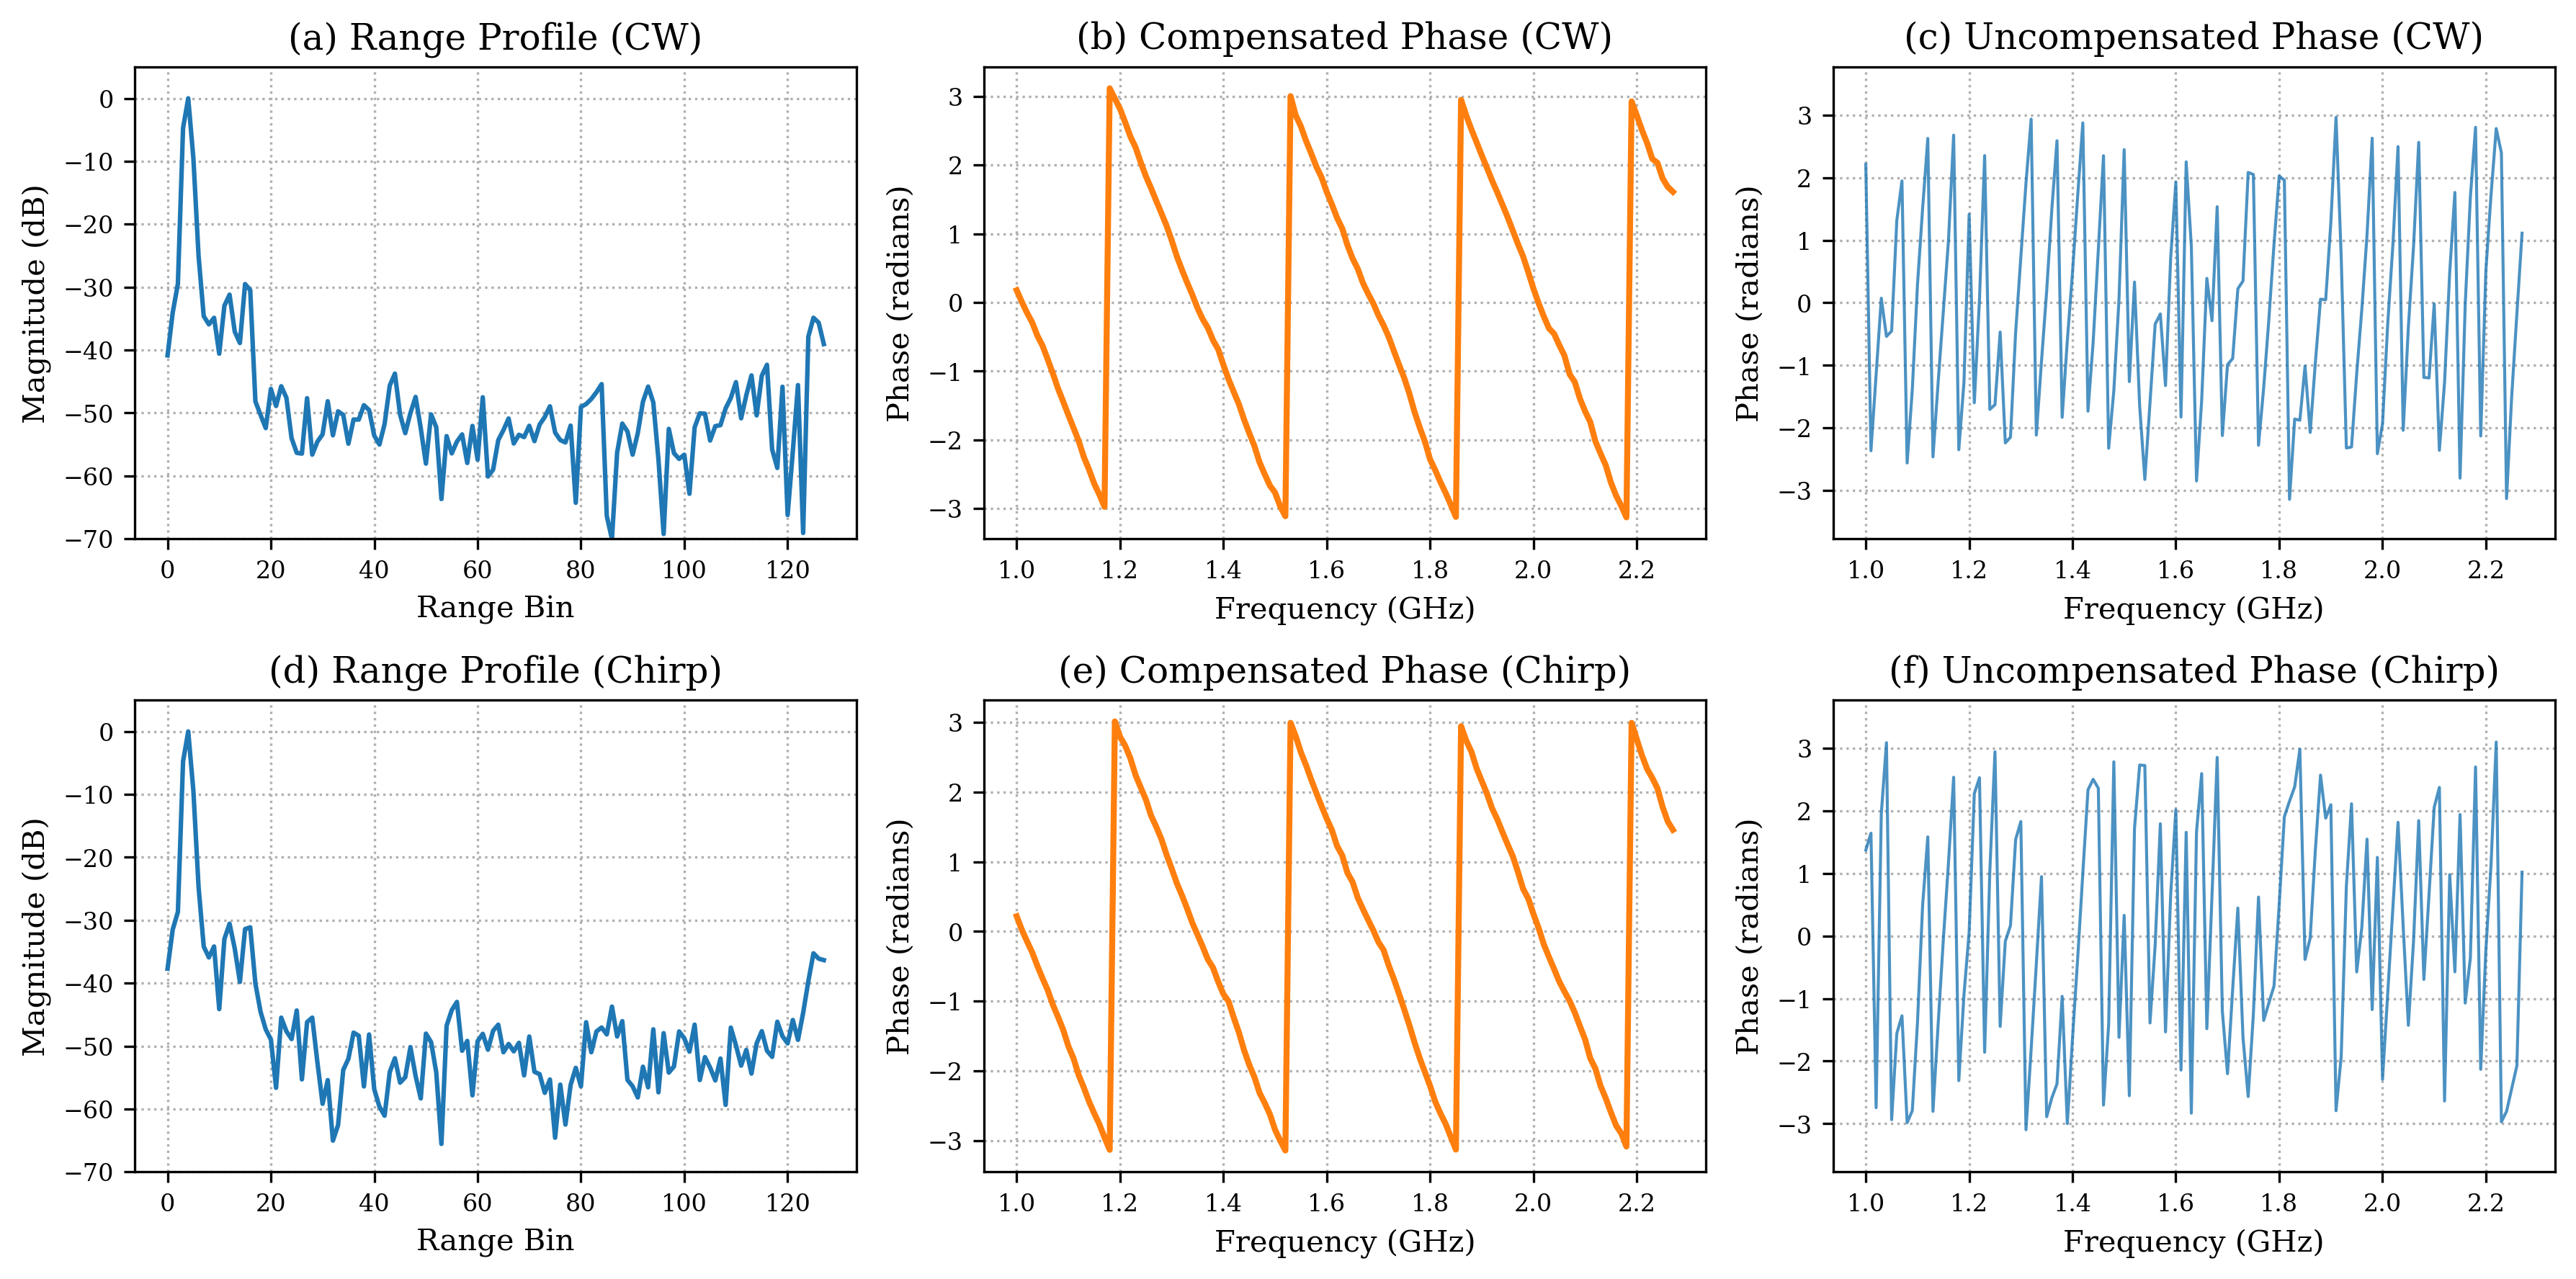

In [28]:
if __name__ == '__main__':
    # --- Call the function with the simulated data ---
    create_sfcw_comparison_figure(
        ascan_cw=ascan_cw,
        compensated_response_cw=compensated_response_cw,
        uncompensated_response_cw=uncompensated_response_cw,
        ascan_chirp=ascan_chirp,
        compensated_response_chirp=compensated_response_chirp,
        uncompensated_response_chirp=uncompensated_response_chirp,
        start_freq_hz=START_FREQ,
        step_freq_hz=STEP_FREQ,
        output_filename="phase_validation.png"
    )